# 2. Ingeniería de Características (Feature Engineering)

En la ingeniería de características tradicional, solíamos mapear manualmente las columnas categóricas en DataFrames de pandas (por ejemplo, convirtiendo `Sex` de 'male'/'female' a 0/1, o aplicando One-Hot encoding manualmente en archivos intermedios como `data/titanic_feature.csv`).

Sin embargo, este enfoque manual tiene desventajas graves en producción:
- Propensión a errores por inconsistencias de categorías en tiempo real.
- Dificultad para mantener scripts paralelos de preprocesamiento.
- Riesgo de fuga de información (data leakage) al escalar los datos antes del split.

### Enfoque Moderno: Pipelines Automatizados

En lugar de crear archivos de datos preprocesados manualmente, utilizaremos el **ColumnTransformer** y **Pipeline** de `scikit-learn`. Este enfoque tiene grandes ventajas:
1. **Automatización Completa**: Cuando el frontend envía los datos crudos en formato JSON (ej. `Sex='female'`, `Embarked='C'`), el preprocesador empaquetado realiza la codificación One-Hot y el escalamiento estándar automáticamente en memoria.
2. **Previene Fugas**: El escalamiento estándar (`StandardScaler`) calcula la media y la desviación estándar **solo en el conjunto de entrenamiento**, y las aplica al de prueba, garantizando una correcta evaluación.
3. **Código Limpio**: Evita tener que escribir funciones de mapeo personalizadas en la API de Flask, haciendo que `app.py` sea sumamente conciso.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import QuantileTransformer

In [2]:
# Demostración del Preprocesamiento del Pipeline
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Cargar los datos limpios
df = pd.read_csv('data/titanic_clean.csv')
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

# Definir columnas
numerical_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
categorical_cols = ['Sex', 'Embarked']

# Crear el transformador de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Ajustar y transformar una muestra para ver los resultados mapeados
X_transformed = preprocessor.fit_transform(X)
print("Datos originales (primer registro):")
print(X.iloc[0])
print("\nDatos transformados por el preprocesador (primer registro):\n", X_transformed[0])

Datos originales (primer registro):
Pclass         3
Sex         male
Age         22.0
SibSp          1
Parch          0
Fare        7.25
Embarked       S
Name: 0, dtype: object

Datos transformados por el preprocesador (primer registro):
 [ 0.82737724 -0.56573646  0.43279337 -0.47367361 -0.50244517  0.
  1.          0.          0.          1.        ]


In [3]:
df = pd.read_csv('./data/titanic_clean.csv')

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [4]:
label_sex = LabelEncoder()
label_embarked = LabelEncoder()

df['Sex'] = label_sex.fit_transform(df['Sex'])
df['Embarked'] = label_embarked.fit_transform(df['Embarked'])

df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
787,0,3,1,8.0,4,1,29.1250,1
603,0,3,1,44.0,0,0,8.0500,2
354,0,3,1,28.0,0,0,7.2250,0
346,1,2,0,40.0,0,0,13.0000,2
796,1,1,0,49.0,0,0,25.9292,2


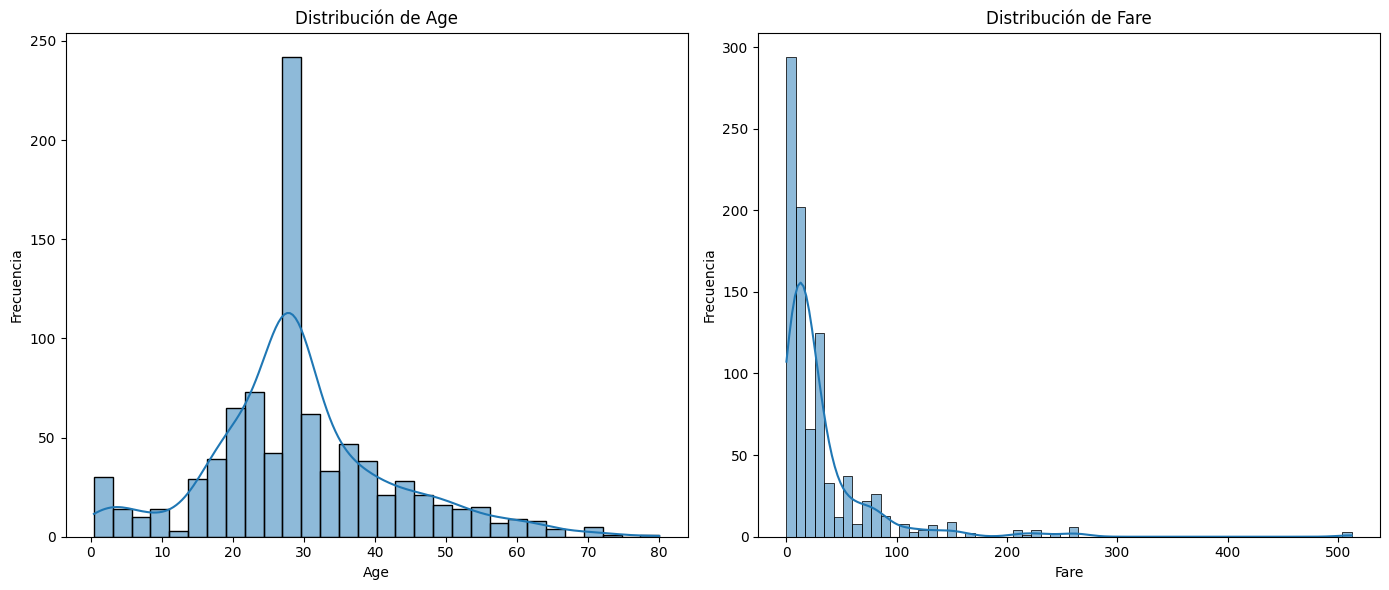

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribución de Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frecuencia')

sns.histplot(df['Fare'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Distribución de Fare')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [6]:
qun_tra_age = QuantileTransformer(
    output_distribution='normal',
    n_quantiles=500
)

qun_tra_fare = QuantileTransformer(
    output_distribution='normal',
    n_quantiles=500
)

df['Age'] = qun_tra_age.fit_transform(df[['Age']])
df['Fare'] = qun_tra_fare.fit_transform(df[['Fare']])

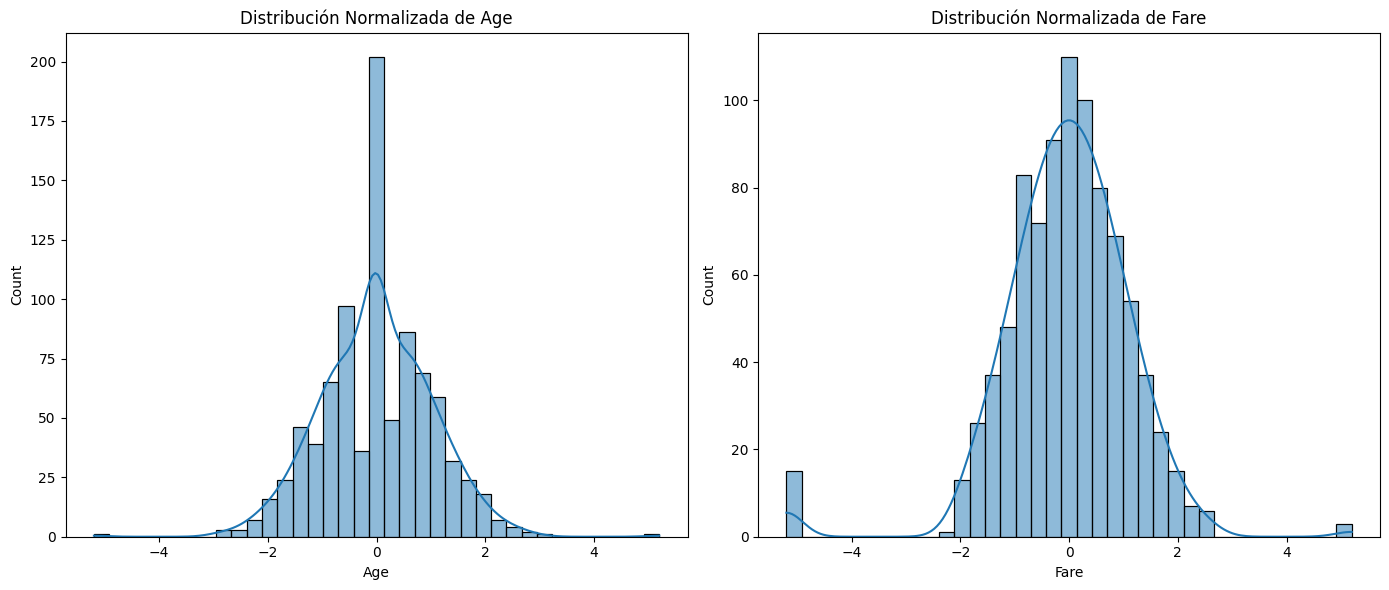

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribución Normalizada de Age')

sns.histplot(df['Fare'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Distribución Normalizada de Fare')

plt.tight_layout()
plt.show()

In [8]:
mms_pclass = MinMaxScaler()
mms_sex = MinMaxScaler()
mms_age = MinMaxScaler()
mms_sibsp = MinMaxScaler()
mms_parch = MinMaxScaler()
mms_fare = MinMaxScaler()
mms_embarked = MinMaxScaler()

In [9]:
df['Pclass'] = mms_pclass.fit_transform(df[['Pclass']])

df['Sex'] = mms_sex.fit_transform(df[['Sex']])

df['Age'] = mms_age.fit_transform(df[['Age']])

df['SibSp'] = mms_sibsp.fit_transform(df[['SibSp']])

df['Parch'] = mms_parch.fit_transform(df[['Parch']])

df['Fare'] = mms_fare.fit_transform(df[['Fare']])

df['Embarked'] = mms_embarked.fit_transform(df[['Embarked']])

In [10]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
799,0,1.0,0.0,0.535318,0.125,0.166667,0.529438,1.0
158,0,1.0,1.0,0.497826,0.000,0.000000,0.459988,1.0
75,0,1.0,1.0,0.456270,0.000,0.000000,0.380088,1.0
516,1,0.5,0.0,0.557904,0.000,0.000000,0.474087,1.0
690,1,0.0,1.0,0.542129,0.125,0.000000,0.603109,1.0


In [11]:
df.to_csv('./data/titanic_procesado.csv', index=False)